## Libraries and Data

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import joblib


In [2]:
# Set File Paths

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

In [3]:
# Load Dataset with Segments# ==============================

energy_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_with_segments.csv")

print("Dataset loaded successfully!")
print("Shape:", energy_df.shape)

energy_df.head()

Dataset loaded successfully!
Shape: (3599, 62)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,estimated_monthly_kwh,supply_factor,estimated_monthly_kwh_adjusted,consumption_category,average_ac_usage_hours,kmeans_cluster,hierarchical_cluster,energy_segment,pca_1,pca_2
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,39.300,0.200000,39.300,High Consumption,0,1,0,Moderate Fan-Heavy Household,2.595801,3.470226
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,12.375,0.250000,12.375,Moderate Consumption,0,1,0,Low-Use Basic Household,-0.172048,1.651435
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,51.225,0.500000,51.225,Very High Consumption,0,1,0,High Consumption Household,-0.117451,-0.030571
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,157.200,0.500000,157.200,Very High Consumption,0,1,0,Appliance-Heavy High Consumption,3.432582,2.378012
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,4.875,0.208333,4.875,Moderate Consumption,0,1,0,Low-Use Basic Household,-1.875530,-0.698028


##### Create Anomaly Detection Features

In [4]:
# Create Anomaly Detection Features

if 'average_ac_usage_hours' not in energy_df.columns:
    energy_df['average_ac_usage_hours'] = np.where(
        energy_df['ac_count'] > 0,
        4,
        0
    )

anomaly_features = [
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'average_ac_usage_hours',
    'estimated_monthly_kwh'
]

anomaly_features = [
    col for col in anomaly_features
    if col in energy_df.columns
]

anomaly_df = energy_df[anomaly_features].copy()

anomaly_df.head()

,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


In [5]:
# Clean Anomaly Dataset

for col in anomaly_features:
    anomaly_df[col] = pd.to_numeric(anomaly_df[col], errors='coerce')

anomaly_df = anomaly_df.replace([np.inf, -np.inf], np.nan)

anomaly_df = anomaly_df.dropna()

print("Clean anomaly dataset shape:", anomaly_df.shape)

anomaly_df.head()

Clean anomaly dataset shape: (3599, 10)


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,39.300
1,10,9,6.0,12,1,1,0,0,0,12.375
2,6,5,12.0,6,2,1,0,0,0,51.225
3,10,10,12.0,20,6,1,1,0,0,157.200
4,6,3,5.0,3,0,0,0,0,0,4.875


In [6]:
# Scale Anomaly Features

anomaly_scaler = StandardScaler()

anomaly_scaled = anomaly_scaler.fit_transform(anomaly_df)

anomaly_scaled[:5]

array([[ 2.1716655 ,  1.04986425, -0.52750445,  1.90059444,  3.16601918,
         1.30466137,  1.14715248, -0.24766679, -0.24766679, -0.0095816 ],
       [ 0.58682802,  1.37641005, -0.18354421,  1.20800548, -0.45884544,
         0.20010332, -0.8717237 , -0.24766679, -0.24766679, -0.47040515],
       [-0.20559072,  0.07022685,  0.84833649, -0.17717243,  0.05899236,
         0.20010332, -0.8717237 , -0.24766679, -0.24766679,  0.19451574],
       [ 0.58682802,  1.70295585,  0.84833649,  3.05490936,  2.13034357,
         0.20010332,  1.14715248, -0.24766679, -0.24766679,  2.00828645],
       [-0.20559072, -0.58286475, -0.35552433, -0.86976138, -0.97668325,
        -0.90445473, -0.8717237 , -0.24766679, -0.24766679, -0.59876826]])

##### Train Isolation Forest Model

In [7]:
# Train Isolation Forest Model
# We will set contamination=0.05.
# This means the model will treat about 5% of households as unusual.

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_model.fit(anomaly_scaled)

print("Anomaly detection model trained successfully!")

Anomaly detection model trained successfully!


In [8]:
# Predict Anomalies

anomaly_labels = anomaly_model.predict(anomaly_scaled)

anomaly_scores = anomaly_model.decision_function(anomaly_scaled)

energy_df.loc[anomaly_df.index, 'anomaly_label'] = anomaly_labels
energy_df.loc[anomaly_df.index, 'anomaly_score'] = anomaly_scores

energy_df['anomaly_status'] = energy_df['anomaly_label'].apply(
    lambda x: 'Anomaly' if x == -1 else 'Normal'
)

energy_df['anomaly_status'].value_counts()

anomaly_status
Normal     3419
Anomaly     180
Name: count, dtype: int64

##### Create High-Consumption Anomaly Warning

In [9]:
# Create High-Consumption Anomaly Warning

high_consumption_threshold = energy_df['estimated_monthly_kwh'].quantile(0.75)

def classify_anomaly(row):
    if row['anomaly_label'] == -1 and row['estimated_monthly_kwh'] >= high_consumption_threshold:
        return "High Consumption Anomaly"
    elif row['anomaly_label'] == -1 and row['estimated_monthly_kwh'] < high_consumption_threshold:
        return "Unusual Low Consumption"
    else:
        return "Normal Usage"


energy_df['anomaly_warning'] = energy_df.apply(classify_anomaly, axis=1)

energy_df['anomaly_warning'].value_counts()

anomaly_warning
Normal Usage                3419
High Consumption Anomaly     165
Unusual Low Consumption       15
Name: count, dtype: int64

In [10]:
# Inspect Anomaly Results

anomaly_preview_columns = [
    'hhid',
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'estimated_service_band',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'estimated_monthly_kwh',
    'consumption_category',
    'energy_segment',
    'anomaly_status',
    'anomaly_warning',
    'anomaly_score'
]

anomaly_preview_columns = [
    col for col in anomaly_preview_columns
    if col in energy_df.columns
]

energy_df[anomaly_preview_columns].head(10)

,hhid,household_size,number_of_rooms,daily_supply_hours,estimated_service_band,light_bulb_count,fan_count,television_count,fridge_count,ac_count,estimated_monthly_kwh,consumption_category,energy_segment,anomaly_status,anomaly_warning,anomaly_score
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,18,8,4.0,Band E,15,8,2,1,0,39.30000,High Consumption,Moderate Fan-Heavy Household,Normal,Normal Usage,0.032675
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,10,9,6.0,Band E,12,1,1,0,0,12.37500,Moderate Consumption,Low-Use Basic Household,Normal,Normal Usage,0.166829
2,435c8e27-517a-46b9-af04-48830e086d7a,6,5,12.0,Band C,6,2,1,0,0,51.22500,Very High Consumption,High Consumption Household,Normal,Normal Usage,0.189698
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,10,10,12.0,Band C,20,6,1,1,0,157.20000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.038461
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,6,3,5.0,Band E,3,0,0,0,0,4.87500,Moderate Consumption,Low-Use Basic Household,Normal,Normal Usage,0.213147
5,d3cb220c-85a6-4f47-b6f3-16afac111a0c,4,5,4.0,Band E,5,1,1,1,0,15.60000,Moderate Consumption,Low-Use Basic Household,Normal,Normal Usage,0.202056
6,2778d899-69d6-4943-896f-de0175716609,9,10,6.0,Band E,10,0,0,0,0,4.80000,Low Consumption,Low-Use Basic Household,Normal,Normal Usage,0.157436
7,6acc2fae-6517-4360-a48a-0b73aa89953c,21,9,8.0,Band D,8,0,0,0,0,6.20000,Moderate Consumption,Low-Use Basic Household,Normal,Normal Usage,0.117702
8,2fb2310c-02b8-4c8c-97de-024b05008625,14,8,5.0,Band E,10,0,2,0,0,9.65625,Moderate Consumption,Low-Use Basic Household,Normal,Normal Usage,0.129047
9,80a0c152-d59a-497e-9ae6-ecd97e4ce53f,8,5,6.0,Band E,5,0,0,0,0,7.38750,Moderate Consumption,Low-Use Basic Household,Normal,Normal Usage,0.210363


In [11]:
# View High-Consumption Anomalies

high_anomalies = energy_df[
    energy_df['anomaly_warning'] == "High Consumption Anomaly"
][anomaly_preview_columns].sort_values(
    by='estimated_monthly_kwh',
    ascending=False
)

high_anomalies.head(10)

,hhid,household_size,number_of_rooms,daily_supply_hours,estimated_service_band,light_bulb_count,fan_count,television_count,fridge_count,ac_count,estimated_monthly_kwh,consumption_category,energy_segment,anomaly_status,anomaly_warning,anomaly_score
3128,89b1b751-e375-463f-9ca4-e519242cc221,6,4,24.0,Band A,7,6,2,1,1,570.60000,Very High Consumption,Cooling-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.070510
3417,f4c2cdfa-f97e-4941-9780-e1d0304d855d,12,7,24.0,Band A,18,8,3,1,0,536.70000,Very High Consumption,Appliance-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.077430
3003,859c5d97-0e56-4665-a78f-0b9e29c2a990,15,12,18.0,Band B,16,12,12,1,0,512.77500,Very High Consumption,Appliance-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.138846
1966,0ae60c53-3ce1-44f9-9a59-051b1c40c988,8,5,24.0,Band A,10,4,2,1,1,468.75000,Very High Consumption,Cooling-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.063660
1967,8e91e265-8fd0-420a-a098-700b4ea050d4,6,5,24.0,Band A,10,4,1,1,1,462.60000,Very High Consumption,Cooling-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.054218
263,1cc9ff18-f753-4843-85e7-5f941c2e674d,22,8,21.0,Band A,22,8,3,1,0,442.57500,Very High Consumption,Appliance-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.098703
1459,df530cc1-3f44-4fab-b2c2-7f4572699cdf,4,9,23.0,Band A,6,3,2,1,1,433.55000,Very High Consumption,Cooling-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.070940
3504,0c6565bf-79d2-4314-b1ba-a465cf071924,35,15,12.0,Band C,30,16,10,1,0,432.30000,Very High Consumption,Appliance-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.172271
2400,02a645ae-ca9f-4c89-9ac1-1d5151f5f23c,7,6,21.0,Band A,10,5,3,1,1,421.96875,Very High Consumption,Cooling-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.079984
3475,1dda71a9-0834-42bd-bfb0-bec9f053c879,6,8,24.0,Band A,13,6,1,1,1,412.95000,Very High Consumption,Cooling-Heavy High Consumption,Anomaly,High Consumption Anomaly,-0.074037


In [12]:
# View Normal High-Consumption Households

normal_high_consumers = energy_df[
    (energy_df['anomaly_warning'] == "Normal Usage") &
    (energy_df['estimated_monthly_kwh'] >= high_consumption_threshold)
][anomaly_preview_columns].sort_values(
    by='estimated_monthly_kwh',
    ascending=False
)

normal_high_consumers.head(10)

,hhid,household_size,number_of_rooms,daily_supply_hours,estimated_service_band,light_bulb_count,fan_count,television_count,fridge_count,ac_count,estimated_monthly_kwh,consumption_category,energy_segment,anomaly_status,anomaly_warning,anomaly_score
3114,65e52a96-b619-4dde-b38f-20bf9f7a3f11,5,4,24.0,Band A,8,3,1,1,0,251.4000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.067374
3408,9d207ecd-6faa-4c1b-b604-1a0da26e74c6,6,3,24.0,Band A,5,2,1,1,0,250.2000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.065239
1671,2d9dbcfd-0f18-4587-ac78-77ecbb4eeb1b,14,6,20.0,Band A,10,4,3,1,0,244.0000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.013370
2105,bac64790-b476-48a0-b19d-070ac0b064c2,13,12,20.0,Band A,15,5,1,1,0,228.7500,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.003921
1452,f450a168-e43f-4bd7-9030-9cf238165e43,6,3,22.0,Band A,6,4,1,1,0,221.1000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.078780
2884,b93be964-ba43-4a4b-a797-3f8103a123ef,6,6,21.0,Band A,12,4,1,1,0,216.8250,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.064164
3538,5ee0a864-c99c-4569-9430-69b3bfc0826d,7,4,22.0,Band A,8,3,2,1,0,215.1875,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.078986
3113,0a480b66-6c05-49b5-ac75-06fd27b93f81,6,3,24.0,Band A,5,3,1,1,0,214.8000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.079424
113,04403e14-8564-4c5b-b26f-b3e766701620,3,3,20.0,Band A,10,3,1,1,0,212.2500,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.079697
1415,83bbaf7d-5957-48e8-8d2d-24f26584f618,6,7,14.0,Band C,21,5,3,1,0,210.7000,Very High Consumption,Appliance-Heavy High Consumption,Normal,Normal Usage,0.012395


##### Anomaly Count Plot

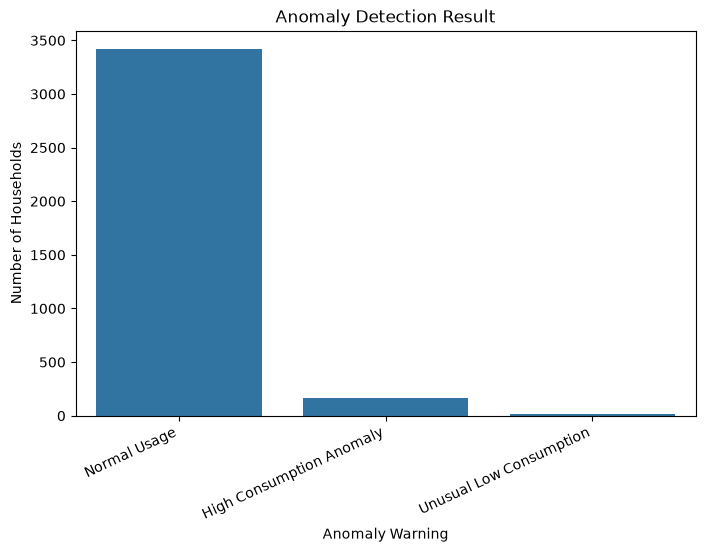

In [13]:
# Anomaly Count Plot

plt.figure(figsize=(8, 5))

sns.countplot(
    data=energy_df,
    x='anomaly_warning',
    order=energy_df['anomaly_warning'].value_counts().index
)

plt.title("Anomaly Detection Result")
plt.xlabel("Anomaly Warning")
plt.ylabel("Number of Households")

plt.xticks(rotation=25, ha='right')

plt.show()

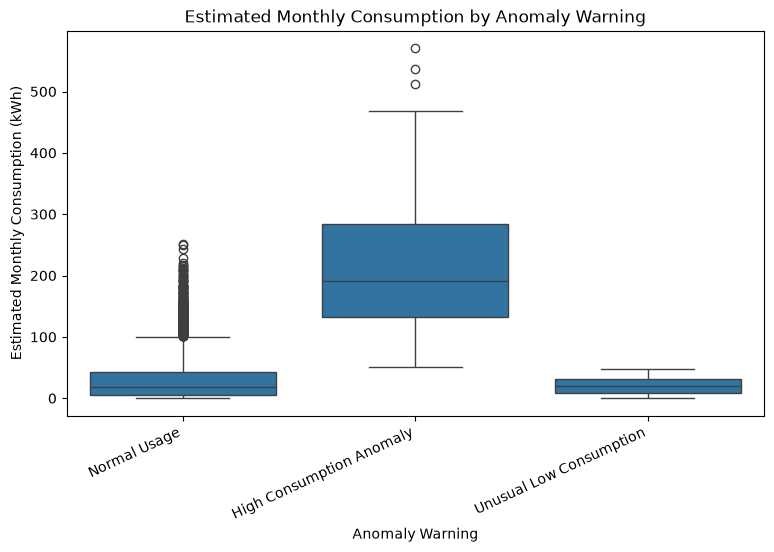

In [14]:
# Consumption Distribution by Anomaly Warning

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=energy_df,
    x='anomaly_warning',
    y='estimated_monthly_kwh',
    order=energy_df['anomaly_warning'].value_counts().index
)

plt.title("Estimated Monthly Consumption by Anomaly Warning")
plt.xlabel("Anomaly Warning")
plt.ylabel("Estimated Monthly Consumption (kWh)")

plt.xticks(rotation=25, ha='right')

plt.show()

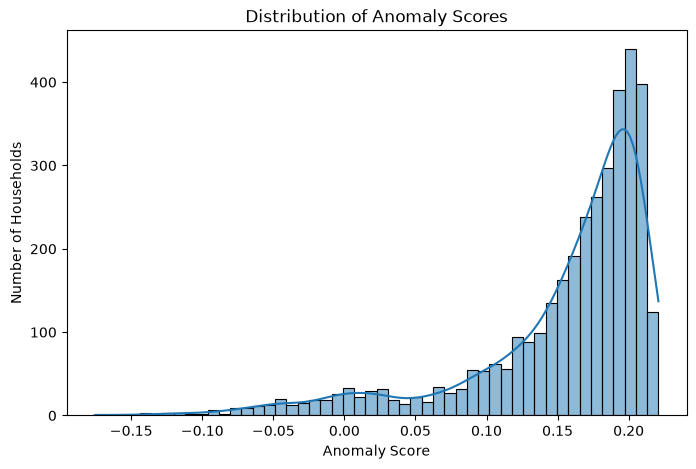

In [15]:
# Anomaly Score Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    energy_df['anomaly_score'],
    kde=True
)

plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Households")

plt.show()

In [16]:
# Anomaly by Energy Segment

if 'energy_segment' in energy_df.columns:
    anomaly_by_segment = pd.crosstab(
        energy_df['energy_segment'],
        energy_df['anomaly_warning']
    )

    anomaly_by_segment

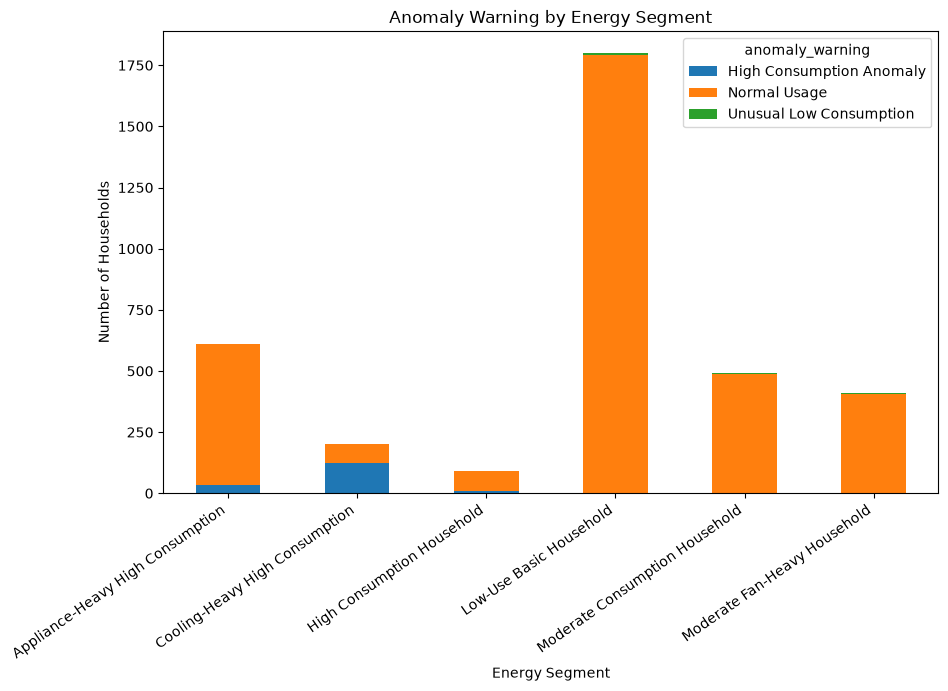

In [17]:
# Visualize Anomaly by Energy Segment

if 'energy_segment' in energy_df.columns:
    anomaly_by_segment.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    plt.title("Anomaly Warning by Energy Segment")
    plt.xlabel("Energy Segment")
    plt.ylabel("Number of Households")

    plt.xticks(rotation=35, ha='right')

    plt.show()

##### Test Anomaly Detection on a Sample Household

In [18]:
# Test Sample Household Anomaly Detection

sample_household = pd.DataFrame({
    'household_size': [4],
    'number_of_rooms': [3],
    'daily_supply_hours': [20],
    'light_bulb_count': [8],
    'fan_count': [3],
    'television_count': [1],
    'fridge_count': [1],
    'ac_count': [1],
    'average_ac_usage_hours': [4],
    'estimated_monthly_kwh': [250]
})

sample_household = sample_household[anomaly_features]

sample_scaled = anomaly_scaler.transform(sample_household)

sample_label = anomaly_model.predict(sample_scaled)[0]

sample_score = anomaly_model.decision_function(sample_scaled)[0]

if sample_label == -1 and sample_household['estimated_monthly_kwh'].iloc[0] >= high_consumption_threshold:
    sample_warning = "High Consumption Anomaly"
elif sample_label == -1:
    sample_warning = "Unusual Low Consumption"
else:
    sample_warning = "Normal Usage"

print("Sample Anomaly Result")
print("---------------------")
print("Anomaly Label:", sample_label)
print("Anomaly Score:", round(sample_score, 4))
print("Anomaly Warning:", sample_warning)

Sample Anomaly Result
---------------------
Anomaly Label: -1
Anomaly Score: -0.0138
Anomaly Warning: High Consumption Anomaly


##### Create Simple App Message Function

In [19]:
# Create Simple App Message Function

def get_anomaly_message(anomaly_warning):
    if anomaly_warning == "High Consumption Anomaly":
        return "This household appears to have unusually high electricity consumption for its profile. Please review high-energy appliances such as AC, fridge, fans, and lighting."
    
    elif anomaly_warning == "Unusual Low Consumption":
        return "This household has unusually low estimated consumption. This may be due to limited electricity supply, few appliances, or very low usage."
    
    else:
        return "No unusual electricity usage pattern was detected for this household."


print(get_anomaly_message(sample_warning))

This household appears to have unusually high electricity consumption for its profile. Please review high-energy appliances such as AC, fridge, fans, and lighting.


##### Save Anomaly Detection Outputs

In [20]:
# Save Anomaly Detection Outputs

joblib.dump(anomaly_model, MODEL_DIR / "energy_anomaly_model.pkl")

joblib.dump(anomaly_scaler, MODEL_DIR / "energy_anomaly_scaler.pkl")

joblib.dump(anomaly_features, MODEL_DIR / "energy_anomaly_features.pkl")

anomaly_thresholds = {
    "high_consumption_threshold": high_consumption_threshold
}

joblib.dump(anomaly_thresholds, MODEL_DIR / "anomaly_thresholds.pkl")

energy_df.to_csv(
    DATA_DIR / "processed" / "energy_household_with_anomalies.csv",
    index=False
)

high_anomalies.to_csv(
    DATA_DIR / "processed" / "high_consumption_anomalies.csv",
    index=False
)

print("Anomaly detection model and outputs saved successfully!")

Anomaly detection model and outputs saved successfully!


In [21]:
# Confirm Saved Files

print("Saved files in models folder:")
for file in MODEL_DIR.iterdir():
    print(file.name)

print("\nSaved files in processed data folder:")
for file in (DATA_DIR / "processed").iterdir():
    print(file.name)

Saved files in models folder:
anomaly_thresholds.pkl
best_model_name.pkl
cluster_segment_mapping.pkl
consumption_category_thresholds.pkl
energy_anomaly_features.pkl
energy_anomaly_model.pkl
energy_anomaly_scaler.pkl
energy_clustering_features.pkl
energy_cluster_pca.pkl
energy_cluster_scaler.pkl
energy_consumption_prediction_model.pkl
energy_kmeans_model.pkl
energy_model_features.pkl
gradient_boosting_energy_model.pkl

Saved files in processed data folder:
clustering_model_comparison.csv
energy_household_base_step2.csv
energy_household_with_anomalies.csv
energy_household_with_segments.csv
energy_household_with_target_step3.csv
energy_modelling_dataset.csv
energy_segment_profile.csv
hierarchical_cluster_profile.csv
high_consumption_anomalies.csv
kmeans_cluster_profile.csv
supervised_model_comparison.csv
supervised_prediction_results.csv
